In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('D:\petProjects\customer-sigmentation\data\Mall_Customers.csv')

print(df.shape)
print(list(df.columns))
print(df.head())

(200, 5)
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


| Столбец                | Перевод       | Что это                                                               |
| ---------------------- | ------------- | --------------------------------------------------------------------- |
| CustomerID             | ID клиента    | Просто номер, не используем в анализе                                 |
| Gender                 | Пол           | Male/Female                                                           |
| Age                    | Возраст       | Лет                                                                   |
| Annual Income (k$)     | Годовой доход | В тысячах долларов (15 = $15,000)                                     |
| Spending Score (1-100) | Оценка трат   | Магазин присвоил от 1 до 100 — насколько активно клиент тратит деньги |

In [3]:
print("Типы данных:")
print(df.dtypes)

print("\nПропущенные значения:")
print(df.isnull().sum())

Типы данных:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Пропущенные значения:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


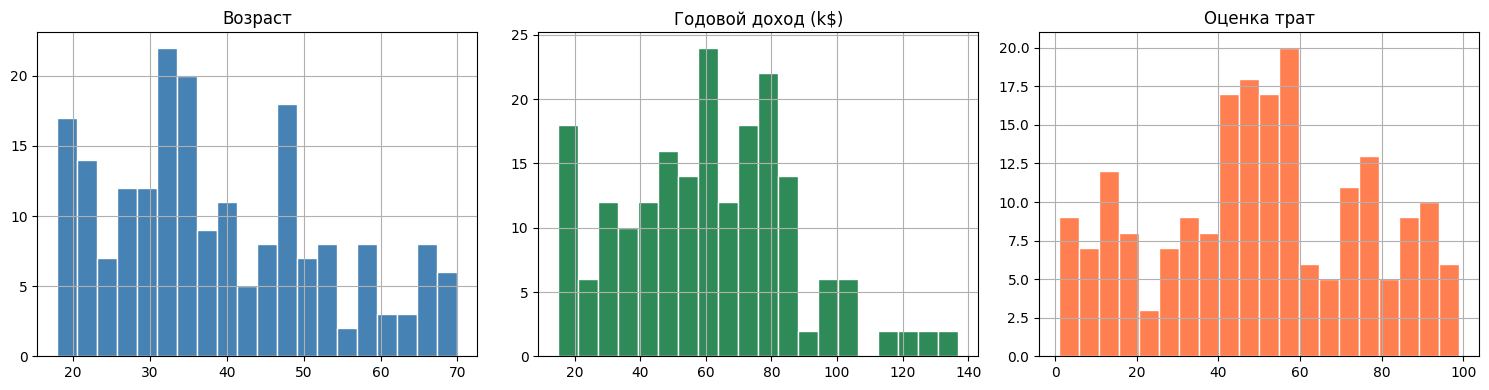

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Age'].hist(ax=axes[0], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Возраст')

df['Annual Income (k$)'].hist(ax=axes[1], bins=20, color='seagreen', edgecolor='white')
axes[1].set_title('Годовой доход (k$)')

df['Spending Score (1-100)'].hist(ax=axes[2], bins=20, color='coral', edgecolor='white')
axes[2].set_title('Оценка трат')

plt.tight_layout()
plt.show()

Тут буду использовать K-Means

Немножко теории)

K-Means — алгоритм **обучения без учителя** (unsupervised learning). Он разбивает набор данных на **K кластеров** так, чтобы точки внутри каждого кластера были максимально похожи друг на друга, а кластеры между собой — максимально различались.

Алгоритм работает итеративно:

1. Случайно размещает K центроидов (центров кластеров)
2. Каждую точку относит к ближайшему центроиду
3. Пересчитывает центроиды как среднее всех точек кластера
4. Повторяет шаги 2–3 до сходимости



Далее возникает вопрос как выбрать К, пальцем в небо тыкать не хочется, но ест метод Локтя

Опять теория)

**WCSS** (Within-Cluster Sum of Squares) — сумма квадратов расстояний от каждой точки до центра её кластера:

$$
WCSS = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

где $\mu_i$ — центроид кластера $C_i$. Чем меньше WCSS, тем плотнее сгруппированы точки внутри кластеров.


## Метод локтя (Elbow Method)

Чтобы выбрать оптимальное K, строится график зависимости WCSS от числа кластеров.

При увеличении K значение WCSS всегда уменьшается — крайний случай K=N (каждая точка сама по себе) даёт WCSS=0. Поэтому просто минимизировать WCSS нельзя.

**Идея метода:** найти точку "перелома" на графике, после которой уменьшение WCSS становится несущественным. Эта точка визуально напоминает локоть руки — отсюда и название.

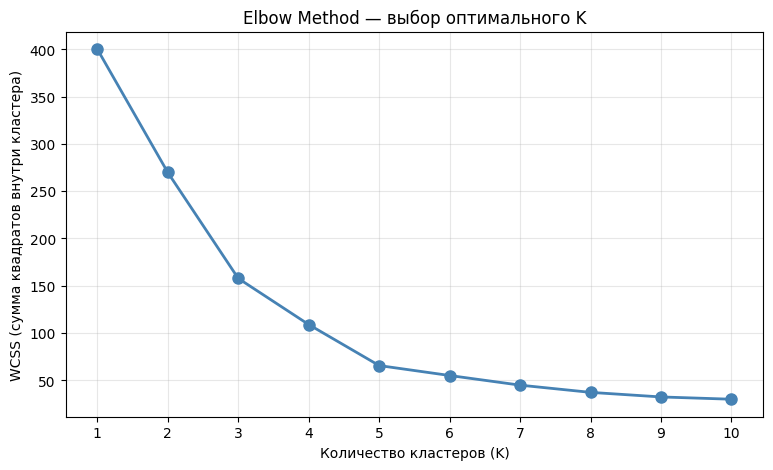

In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Масштабируем
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Считаем WCSS для разных K
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title('Elbow Method — выбор оптимального K')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('WCSS (сумма квадратов внутри кластера)')
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.show()

Ну по графику видно, что улучшение не особо происходит после К = 5

In [7]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nРаспределение клиентов по кластерам:")
print(df['Cluster'].value_counts().sort_index())


Распределение клиентов по кластерам:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


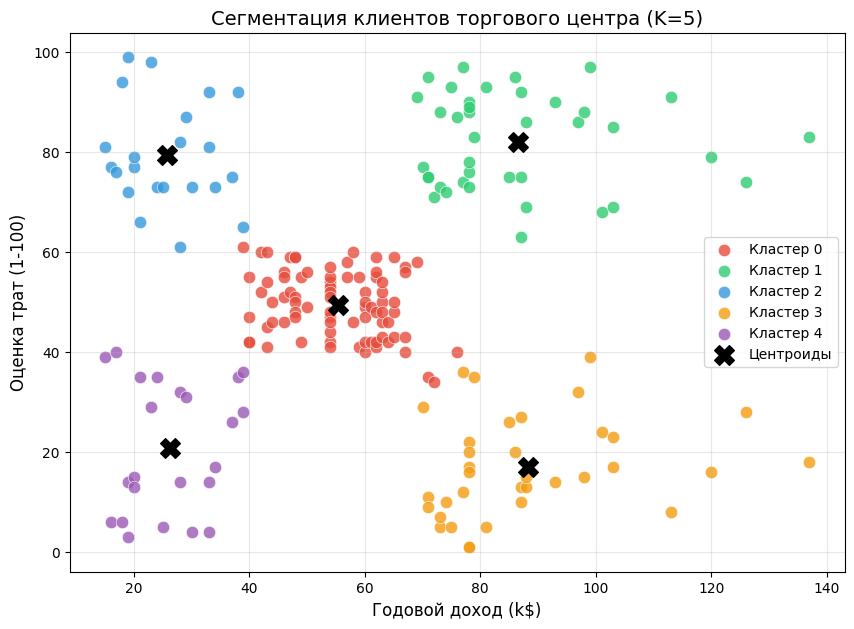

In [8]:
# Цвета и названия кластеров
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']
cluster_names = {
    0: 'Кластер 0',
    1: 'Кластер 1', 
    2: 'Кластер 2',
    3: 'Кластер 3',
    4: 'Кластер 4'
}

plt.figure(figsize=(10, 7))

# Рисуем каждый кластер отдельно
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        c=colors[i], label=cluster_names[i],
        s=80, alpha=0.8, edgecolors='white', linewidth=0.5
    )

# Центроиды
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:, 0], centers[:, 1],
    c='black', marker='X', s=200,
    label='Центроиды', zorder=5
)

plt.title('Сегментация клиентов торгового центра (K=5)', fontsize=14)
plt.xlabel('Годовой доход (k$)', fontsize=12)
plt.ylabel('Оценка трат (1-100)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
summary = df.groupby('Cluster').agg(
    Количество=('CustomerID', 'count'),
    Средний_возраст=('Age', 'mean'),
    Средний_доход=('Annual Income (k$)', 'mean'),
    Средние_траты=('Spending Score (1-100)', 'mean')
).round(1)

print(summary)

         Количество  Средний_возраст  Средний_доход  Средние_траты
Cluster                                                           
0                81             42.7           55.3           49.5
1                39             32.7           86.5           82.1
2                22             25.3           25.7           79.4
3                35             41.1           88.2           17.1
4                23             45.2           26.3           20.9


## Интерпретация кластеров

| Кластер | Клиентов | Доход | Траты | Профиль |
|---------|----------|-------|-------|---------|
| 0 | 81 | средний ($55k) | средние (49) | Обычные клиенты — основная аудитория |
| 1 | 39 | высокий ($87k) | высокие (82) | VIP — приоритетная группа для премиум-предложений |
| 2 | 22 | низкий ($26k) | высокие (79) | Лояльные — любят шопинг несмотря на доход |
| 3 | 35 | высокий ($88k) | низкие (17) | Потенциал — богатые но не вовлечённые |
| 4 | 23 | низкий ($26k) | низкие (21) |  Пассивные — наименее приоритетная группа |

**Самый ценный вывод:** Кластер 3 — богатые клиенты которые почти не тратят.